### Plot scaling

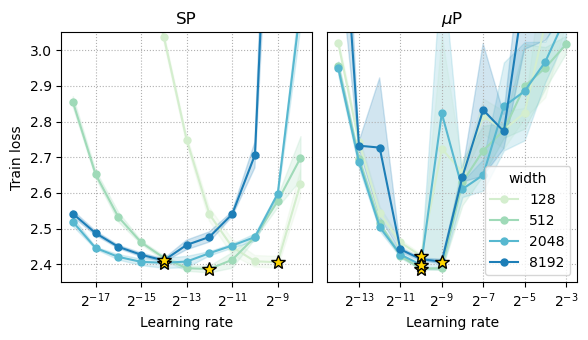

In [7]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

rootm = "/project/home/p200535/project/nanogpt-mup/shakespeare_char"
parameterizations = [
    ('sp', r'SP'),
    ('mup', r'$\mu$P'),
]
seeds = [1, 2, 3]
widths = [
    128,
    512,
    2048,
    8192,
]
lrs = [
    0.125,
    0.0625,
    0.03125,
    0.015625,
    0.0078125,
    0.00390625,
    0.001953125,
    0.0009765625,
    0.00048828125,
    0.000244140625,
    0.0001220703125,
    0.00006103515625,
    0.00003051757812,
    0.00001525878906,
    0.000007629394531,
    0.000003814697266,
]

cmap = plt.get_cmap("GnBu", len(widths) + 2)
n_cols = len(parameterizations)
n_rows = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3.5*n_rows))

for parameterization_idx, (parameterization, parameterization_str) in enumerate(parameterizations):
    ax = axes[parameterization_idx]
    optimal_lrs = []
    optimal_losses = []
    for width_idx, width in enumerate(widths):
        mean_losses = []
        sem_losses = []
        lrs_to_plot = []
        for lr in lrs:
            losses = []
            for seed in seeds:
                job_name = f'width{width}_depth2_seed{seed}_lr{lr:.20f}'.rstrip('0')
                csv_path = os.path.join(rootm, parameterization, job_name, 'log.csv')
                if os.path.exists(csv_path):
                    ckpt_df = pd.read_csv(csv_path)
                    losses.append(ckpt_df['train/loss'].min())
                    # losses.append(ckpt_df['train/loss'].values[-1])
                # else:
                #     print(f'Missing {csv_path}')
            if len(losses):
                mean_losses.append(np.mean(losses))
                sem_losses.append(np.std(losses, ddof=1) / np.sqrt(len(losses)))
                lrs_to_plot.append(lr)
        
        mean_losses = np.array(mean_losses)
        sem_losses = np.array(sem_losses)
        ax.plot(lrs_to_plot, mean_losses, label=width, marker='o', markersize=5, color=cmap(width_idx+1))
        ax.fill_between(lrs_to_plot, mean_losses-sem_losses, mean_losses+sem_losses, color=cmap(width_idx+1), alpha=0.2)
            
        if len(mean_losses):
            optimum_idx = np.argmin(mean_losses)
            optimal_lrs.append(lrs_to_plot[optimum_idx])
            optimal_losses.append(mean_losses[optimum_idx])
        
    ax.plot(optimal_lrs, optimal_losses, color='gold', markeredgecolor="black", markersize=10, linestyle='none', marker='*')
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Learning rate')
    ax.set_title(parameterization_str)
    ax.set_ylim(2.35, 3.05)
    ax.grid(True, linestyle="dotted")

axes[1].legend(title='width', loc='lower right')
axes[0].set_ylabel('Train loss')
axes[1].yaxis.set_ticklabels([])
axes[1].tick_params(axis='y', length=0, width=0)
plt.tight_layout()

### Plot merging

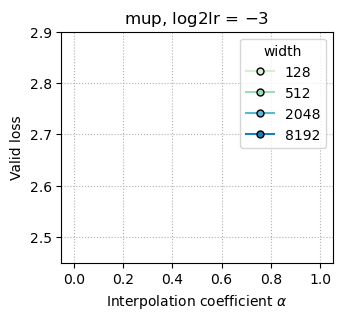

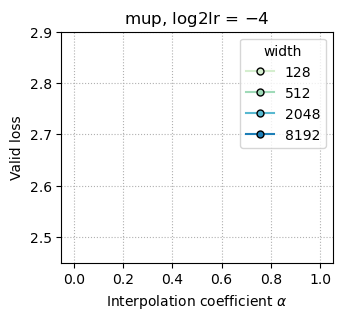

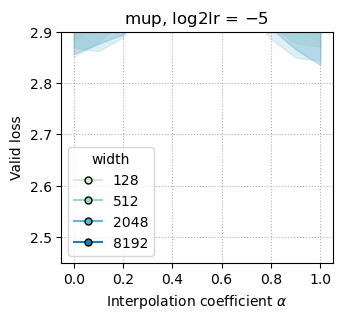

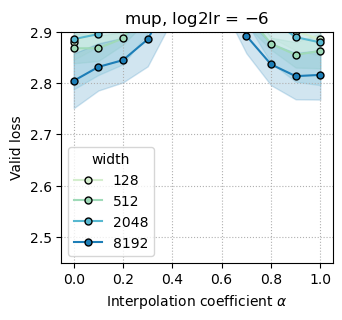

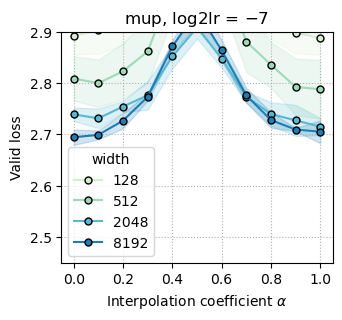

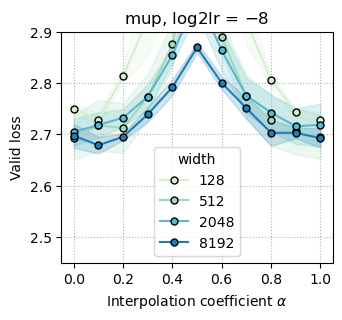

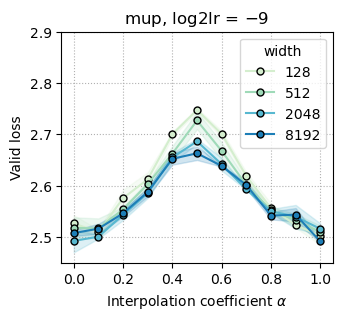

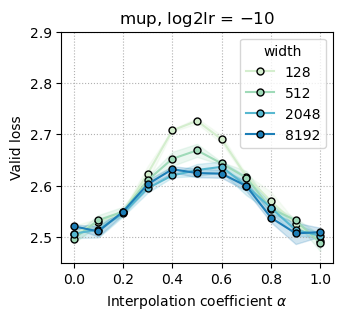

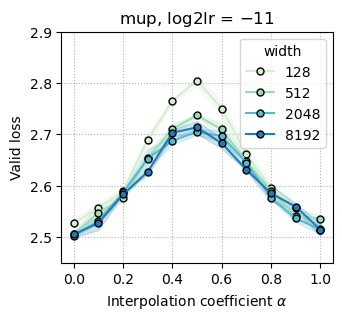

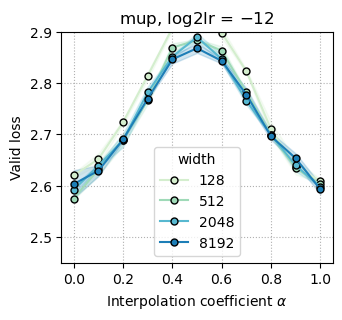

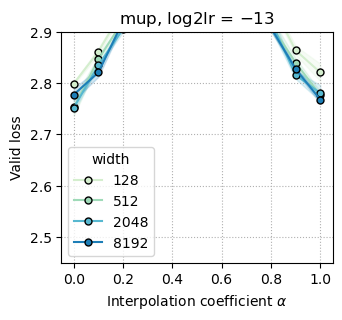

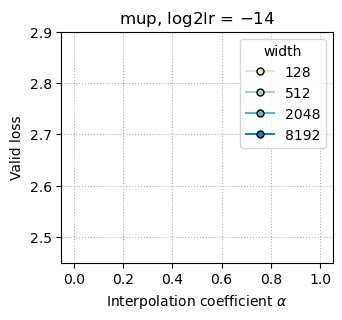

In [8]:
import json
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

init = "mup"
with open(f"./merge_{init}.json", "r") as f:
    summary = json.load(f)
    
if init == "mup":
    lrs = [
        0.125,
        0.0625,
        0.03125,
        0.015625,
        0.0078125,
        0.00390625,
        0.001953125,
        0.0009765625,
        0.00048828125,
        0.000244140625,
        0.0001220703125,
        0.00006103515625
    ]
elif init == "sp":
    lrs = [
        0.00390625,
        0.001953125,
        0.0009765625,
        0.00048828125,
        0.000244140625,
        0.0001220703125,
        0.00006103515625,
        0.00003051757812,
        0.00001525878906,
        0.000007629394531,
        0.000003814697266
    ]
else:
    raise ValueError

widths = [128, 512, 2048, 8192]
metric = "vl_loss"
ylabel = {
    "vl_loss": "Valid loss",
    "tr_loss": "Train loss",
}
seeds = [1, 2, 3]

for lr in lrs:
    _, axs = plt.subplots(1, 1, figsize=(3.5, 3.0))
    cmap = plt.get_cmap("GnBu", len(widths) + 2)

    x = np.linspace(0, 1, 9 + 2)
    for i, width in enumerate(widths):
        v = [summary[str(s)][str(lr)][str(width)][metric] for s in seeds]
        y = np.mean(v, axis=0)
        yerr = np.std(v, axis=0, ddof=1) / np.sqrt(len(v)) 

        axs.plot(
            x,
            y,
            "-",
            marker="o",
            markeredgecolor="black",
            markersize=5,
            color=cmap(i + 1),
            label=width,
        )
        axs.fill_between(
            x,
            y - yerr,
            y + yerr,
            color=cmap(i + 1),
            alpha=0.2,
        )

    lr = str(int(np.log2(lr)))[1:]
    axs.set_title(f"{init}, log2lr = $\minus${lr}")
    axs.set_xlabel(r"Interpolation coefficient $\alpha$")
    axs.set_ylabel(ylabel[metric])
    axs.grid(True, linestyle="dotted")
    axs.legend(title="width")
    
    if init == "mup":
        axs.set_ylim(2.45, 2.9) 
    
    # plt.savefig(
    #     f"figures/{metric}/merge_{init}_lr{lr}.pdf",
    #     format="pdf",
    #     dpi=300,
    #     bbox_inches="tight",
    # )

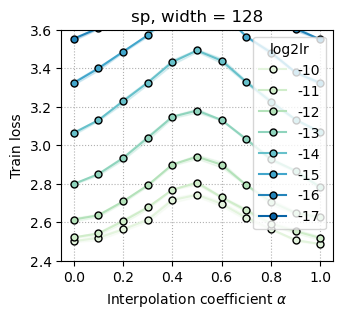

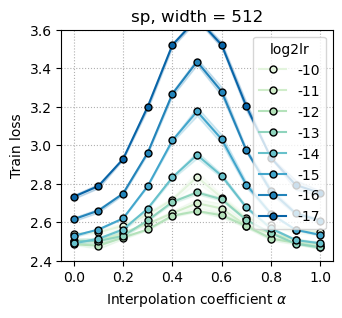

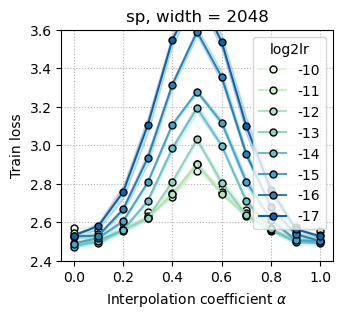

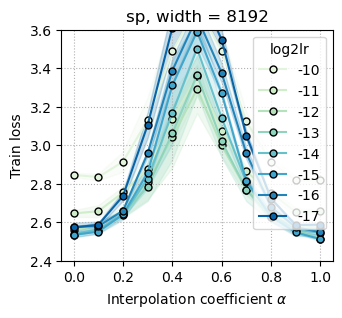

In [8]:
import json
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

init = "sp"
with open(f"./merge_{init}.json", "r") as f:
    summary = json.load(f)
    
if init == "mup":
    lrs = [
        # 0.125,
        # 0.0625,
        # 0.03125,
        0.015625,
        0.0078125,
        0.00390625,
        0.001953125,
        0.0009765625,
        0.00048828125,
        0.000244140625,
        0.0001220703125,
        0.00006103515625
    ]
elif init == "sp":
    lrs = [
        # 0.00390625,
        # 0.001953125,
        0.0009765625,
        0.00048828125,
        0.000244140625,
        0.0001220703125,
        0.00006103515625,
        0.00003051757812,
        0.00001525878906,
        0.000007629394531,
        # 0.000003814697266
    ]
else:
    raise ValueError

widths = [128, 512, 2048, 8192]
metric = "tr_loss"
ylabel = {
    "vl_loss": "Valid loss",
    "tr_loss": "Train loss",
}
seeds = [1, 2, 3]

for width in widths:
    _, axs = plt.subplots(1, 1, figsize=(3.5, 3.0))
    cmap = plt.get_cmap("GnBu", len(lrs) + 2)

    x = np.linspace(0, 1, 9 + 2)
    for i, lr in enumerate(lrs):
        v = [summary[str(s)][str(lr)][str(width)][metric] for s in seeds]
        y = np.mean(v, axis=0)
        yerr = np.std(v, axis=0, ddof=1) / np.sqrt(len(v)) 

        lr = str(int(np.log2(lr)))
        axs.plot(
            x,
            y,
            "-",
            marker="o",
            markeredgecolor="black",
            markersize=5,
            color=cmap(i + 1),
            label=lr,
        )
        axs.fill_between(
            x,
            y - yerr,
            y + yerr,
            color=cmap(i + 1),
            alpha=0.2,
        )

    axs.set_title(f"{init}, width = {width}")
    axs.set_xlabel(r"Interpolation coefficient $\alpha$")
    axs.set_ylabel(ylabel[metric])
    axs.grid(True, linestyle="dotted")
    axs.legend(title="log2lr", loc="upper right")

    if init == "sp":
        axs.set_ylim(2.40, 3.6)
    elif init == "mup":
        axs.set_ylim(2.40, 3.6)

    # plt.savefig(
    #     f"figures/{metric}/merge_{init}_width{width}.pdf",
    #     format="pdf",
    #     dpi=300,
    #     bbox_inches="tight",
    # )